# **Práctica Visión**

- **Autores:** Jose María De Miguel, Miguel Ángel Rojo y Sandra Millán
- **Asignatura:** Visión por Computador
- **Profesores:** D. Luis Baumela y D. Roberto Valle
- **Fecha:** 02/11/25



xView (http://xviewdataset.org/) is a large publicly available object detection data set, with approximately 1
million objects across 60 categories. It contains manually annotated images from different scenes around the
world, acquired using the WorldView-3 satellite at 0.3m ground sample distance. There are 846 annotated
images in total. For this practice, we divide these annotations into 761 and 85 images for training and testing
respectively.

For object detection, we extract cropped images of size 640x640. We focus only on 4 object categories, and
discard cropped images containing fewer than five objects of interest. As a result, we will only use 7606 and
852 images for training and testing respectively for the image detection task. Follow the link below to
download the detection data set “xview_detection”: https://drive.upm.es/s/P7nEf3Bygns7tbM  

For image recognition, we crop previous images using their annotated bounding boxes to extract a subset of
objects of interest. We focus only on 13 object categories. In this way, we collected 18746 and 2365 images
for training and testing respectively. The resulting images are resized to 224x224. Follow the link below to
download the classification benchmark “xview_recognition”: https://drive.upm.es/s/2DDPE2zHw5dbM3G

### **Librerías y carga de datos**

In [1]:
"""import tensorflow as tf
!nvidia-smi"""
# (Opcional) actualizar pip
!python -m pip install -U pip

# Ver tu versión de Python (por compatibilidad de wheel)
!python -V

# Instalar rasterio
!python -m pip install rasterio



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Python 3.11.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 63.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rasterio]


In [ ]:
# Librerías adicionales
import tensorflow as tf
import random
import math
import keras
from tqdm.notebook import tqdm
from typing import Dict, List, Tuple
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# Librerías para generación de datos de imágenes
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Librerías para visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import matplotlib.image as mpimg

# Librerías para construir modelos de redes
from keras.models import Sequential, load_model
from keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, LeakyReLU,
    Dropout, LayerNormalization, Input, ZeroPadding2D, Activation,
    AveragePooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D, Concatenate,
    RandomTranslation
)
from keras.optimizers.schedules import PiecewiseConstantDecay
from keras.optimizers import SGD, Adam, RMSprop
from keras.initializers import he_normal, VarianceScaling, Orthogonal, GlorotNormal
from keras.applications.inception_v3 import preprocess_input
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler

# Librerías para trabajar con imágenes
from PIL import Image
#import cv2
from skimage.transform import resize
from scipy.ndimage import rotate

# Librerías para operaciones del sistema operativo y manipulación de datos
import os
import pickle
import tarfile
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    accuracy_score, top_k_accuracy_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
import rasterio

import os
import shutil
import random
from tqdm import tqdm

# ===== RUTAS =====
# Carpeta del dataset montado (solo lectura)
src_root = "../PROJECT/xview_recognition/"

train_src = os.path.join(src_root, "xview_train")
test_src  = os.path.join(src_root, "xview_test")



import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}



def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    
    # Si filename ya es absoluto, úsalo tal cual; si no, antepón src_root
    path = filename if os.path.isabs(filename) else os.path.join(src_root, filename)
    
    src_raster = rasterio.open(path, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img


json_file = src_root + '/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

2026-01-07 17:16:05.403168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767806165.570426      21 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767806165.625157      21 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}
Number of training images: 16871
Number of validation images: 1875


In [3]:
import numpy as np
from collections import Counter

# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

# índice: categoría -> índice (debe coincidir con tu one-hot)
cat2idx = {cat_name: i for i, cat_name in enumerate(categories.values())}

y_idx_train = [cat2idx[obj.category] for _, obj in objs_train]
counts = Counter(y_idx_train)
n_classes = len(categories)
total = len(y_idx_train)

# fórmula “balanced”
class_weight = {c: total / (n_classes * counts[c]) for c in range(n_classes)}
print("Class counts:", counts)
print("Class weights:", class_weight)


Class counts: Counter({8: 3231, 1: 2995, 3: 1969, 2: 1594, 11: 1388, 10: 1317, 6: 1118, 4: 960, 7: 708, 5: 633, 0: 576, 12: 280, 9: 102})
Class weights: {0: 2.2530715811965814, 1: 0.4333119301399769, 2: 0.8141588649744234, 3: 0.6591006758604524, 4: 1.3518429487179486, 5: 2.0501883582452303, 6: 1.1607953763588825, 7: 1.8330073880921338, 8: 0.40166178606290026, 9: 12.723227752639517, 10: 0.9853980491793704, 11: 0.9349922411882066, 12: 4.63489010989011}


In [4]:
def generator_images_sw(objs, batch_size, do_shuffle, cat2idx, class_weight):
    n_classes = len(cat2idx)
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        for i in range(0, len(objs), batch_size):
            group = objs[i:i+batch_size]
            images, labels_idx = [], []
            for (filename, obj) in group:
                img = load_geoimage(filename)
                images.append(img)
                labels_idx.append(cat2idx[obj.category])

            X = np.asarray(images, dtype=np.float32)

            Y = np.zeros((len(group), n_classes), dtype=np.float32)
            Y[np.arange(len(group)), labels_idx] = 1.0

            # sample weights por ejemplo (según la clase)
            sw = np.array([class_weight[j] for j in labels_idx], dtype=np.float32)

            yield X, Y, sw


def generator_images_val(objs, batch_size, do_shuffle, cat2idx):
    n_classes = len(cat2idx)
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        for i in range(0, len(objs), batch_size):
            group = objs[i:i+batch_size]
            images, labels_idx = [], []
            for (filename, obj) in group:
                img = load_geoimage(filename)
                images.append(img)
                labels_idx.append(cat2idx[obj.category])

            X = np.asarray(images, dtype=np.float32)
            Y = np.zeros((len(group), n_classes), dtype=np.float32)
            Y[np.arange(len(group)), labels_idx] = 1.0

            yield X, Y





batch_size = 64

train_generator = generator_images_sw(
    objs_train, batch_size, True, cat2idx, class_weight
)
valid_generator = generator_images_val(
    objs_valid, batch_size, False, cat2idx
)
#This block only checks that the immages have been loading correctly
try:
    L = len(train_generator)  # works for Sequence / ImageDataGenerator / tf.data via .__len__
    print("len(train_generator) =", L)
except TypeError:
    print("len(train_generator) unavailable (plain Python generator?)")

# 2) Try to actually get one batch
it_train = iter(train_generator)
try:
    first = next(it_train)
    assert isinstance(first, tuple), f"Generator must yield a tuple, got {type(first)}"
    print("First train batch shapes:",
          [getattr(x, "shape", type(x)) for x in (first if isinstance(first, tuple) else (first,))])
except StopIteration:
    raise RuntimeError("train_generator yielded 0 batches. Check your data and generator logic.")

# 3) Do the same for validation
it_valid = iter(valid_generator)
try:
    first_v = next(it_valid)
    assert isinstance(first_v, tuple), f"Validation generator must yield a tuple, got {type(first_v)}"
    print("First valid batch shapes:",
          [getattr(x, "shape", type(x)) for x in (first_v if isinstance(first_v, tuple) else (first_v,))])
except StopIteration:
    raise RuntimeError("valid_generator yielded 0 batches. Check your data and generator logic.")

len(train_generator) unavailable (plain Python generator?)
First train batch shapes: [(64, 224, 224, 3), (64, 13), (64,)]
First valid batch shapes: [(64, 224, 224, 3), (64, 13)]


## **Modelo: Creación y rendimiento**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.applications.densenet import preprocess_input

img_size = (224, 224)
num_classes = 13

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# Base DenseNet169 SIN pesos preentrenados
base_model = DenseNet169(
    include_top=False,
    weights=None,   # puedes cambiar a "imagenet" si quieres transfer learning
    input_shape=img_size + (3,)
)

base_model.trainable = True

inputs = layers.Input(shape=img_size + (3,))

x = data_augmentation(inputs)

#  Preprocesado correcto para DenseNet
x = preprocess_input(x)

x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)



I0000 00:00:1767806188.747859      21 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=Adam(1e-4),
    loss= tf.keras.losses.CategoricalCrossentropy(),  
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint("resnet101_head.h5", save_best_only=True, monitor="val_loss"),
]

steps_per_epoch  = int(np.ceil(len(objs_train) / batch_size))
validation_steps = int(np.ceil(len(objs_valid) / batch_size))

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=200,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

# history es lo que devuelve model.fit()
with open("history.json", "w") as f:
    json.dump(history.history, f)

"""

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=200,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)"""

Epoch 1/200


I0000 00:00:1767806304.558729      77 cuda_dnn.cc:529] Loaded cuDNN version 90300


264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1320 - loss: 2.7003

264/264 ━━━━━━━━━━━━━━━━━━━━ 778s 3s/step - accuracy: 0.1321 - loss: 2.6997 - val_accuracy: 0.0315 - val_loss: 3.5503
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2432 - loss: 2.1938

264/264 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.2433 - loss: 2.1935 - val_accuracy: 0.1184 - val_loss: 2.6753
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2952 - loss: 1.9536

...

264/264 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.7410 - loss: 0.5793 - val_accuracy: 0.6597 - val_loss: 1.0069
Epoch 37/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7478 - loss: 0.5402 - val_accuracy: 0.5365 - val_loss: 1.4293
Epoch 38/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.7460 - loss: 0.5487 - val_accuracy: 0.6192 - val_loss: 1.1970
Epoch 39/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7305 - loss: 0.6210 - val_accuracy: 0.5744 - val_loss: 1.3630
Epoch 40/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7555 - loss: 0.5371 - val_accuracy: 0.6395 - val_loss: 1.2479
Epoch 41/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7593 - loss: 0.5130 - val_accuracy: 0.6128 - val_loss: 1.2996
Epoch 42/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7118 - loss: 0.6826 - val_accuracy: 0.6277 - val_loss: 1.1142
Epoch 43/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7690 - loss: 0.4821

264/264 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.7689 - loss: 0.4823 - val_accuracy: 0.7173 - val_loss: 0.9129
Epoch 44/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7735 - loss: 0.4858

264/264 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.7735 - loss: 0.4859 - val_accuracy: 0.7077 - val_loss: 0.8905
Epoch 45/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.7768 - loss: 0.4884 - val_accuracy: 0.6944 - val_loss: 0.9873
Epoch 46/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.7840 - loss: 0.4533 - val_accuracy: 0.6976 - val_loss: 0.9386
Epoch 47/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8021 - loss: 0.4167 - val_accuracy: 0.7072 - val_loss: 0.9110
Epoch 48/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8034 - loss: 0.4095 - val_accuracy: 0.6933 - val_loss: 0.9776
Epoch 49/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7976 - loss: 0.4180

264/264 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.7976 - loss: 0.4180 - val_accuracy: 0.7280 - val_loss: 0.8358
Epoch 50/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8156 - loss: 0.3817 - val_accuracy: 0.6779 - val_loss: 1.2046
Epoch 51/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8248 - loss: 0.3696 - val_accuracy: 0.5888 - val_loss: 1.4214
Epoch 52/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8145 - loss: 0.3734 - val_accuracy: 0.6443 - val_loss: 1.2333
Epoch 53/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8197 - loss: 0.3729 - val_accuracy: 0.6976 - val_loss: 0.9793
Epoch 54/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8249 - loss: 0.3619 - val_accuracy: 0.6448 - val_loss: 1.2518
Epoch 55/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8319 - loss: 0.3358 - val_accuracy: 0.7003 - val_loss: 1.0172
Epoch 56/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8450 - loss: 0.3319 - val_a

'\n\nhistory = model.fit(\n    train_generator,\n    validation_data=valid_generator,\n    epochs=200,\n    steps_per_epoch=steps_per_epoch,\n    validation_steps=validation_steps,\n    callbacks=[reduce_lr, early_stop],\n    verbose=1\n)'

In [ ]:
with open("recognition_sin_tl.json", "w") as f:
    json.dump(history.history, f)


model.save("recognition_sin_tl.keras")
# Iters 50



Métricas del modelo con train y validation

In [ ]:



model = tf.keras.models.load_model("recognition_sin_tl.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 624 variables whereas the saved optimizer has 1246 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [9]:

validation_steps = int(np.ceil(len(objs_valid) / batch_size))

val_loss, val_acc = model.evaluate(
    valid_generator,
    steps=validation_steps,
    verbose=1   # para ver barra de progreso con x/y
)
print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)

#print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step - accuracy: 0.7126 - loss: 0.9048
Validation loss: 0.8357646465301514
Validation accuracy: 0.7279999852180481


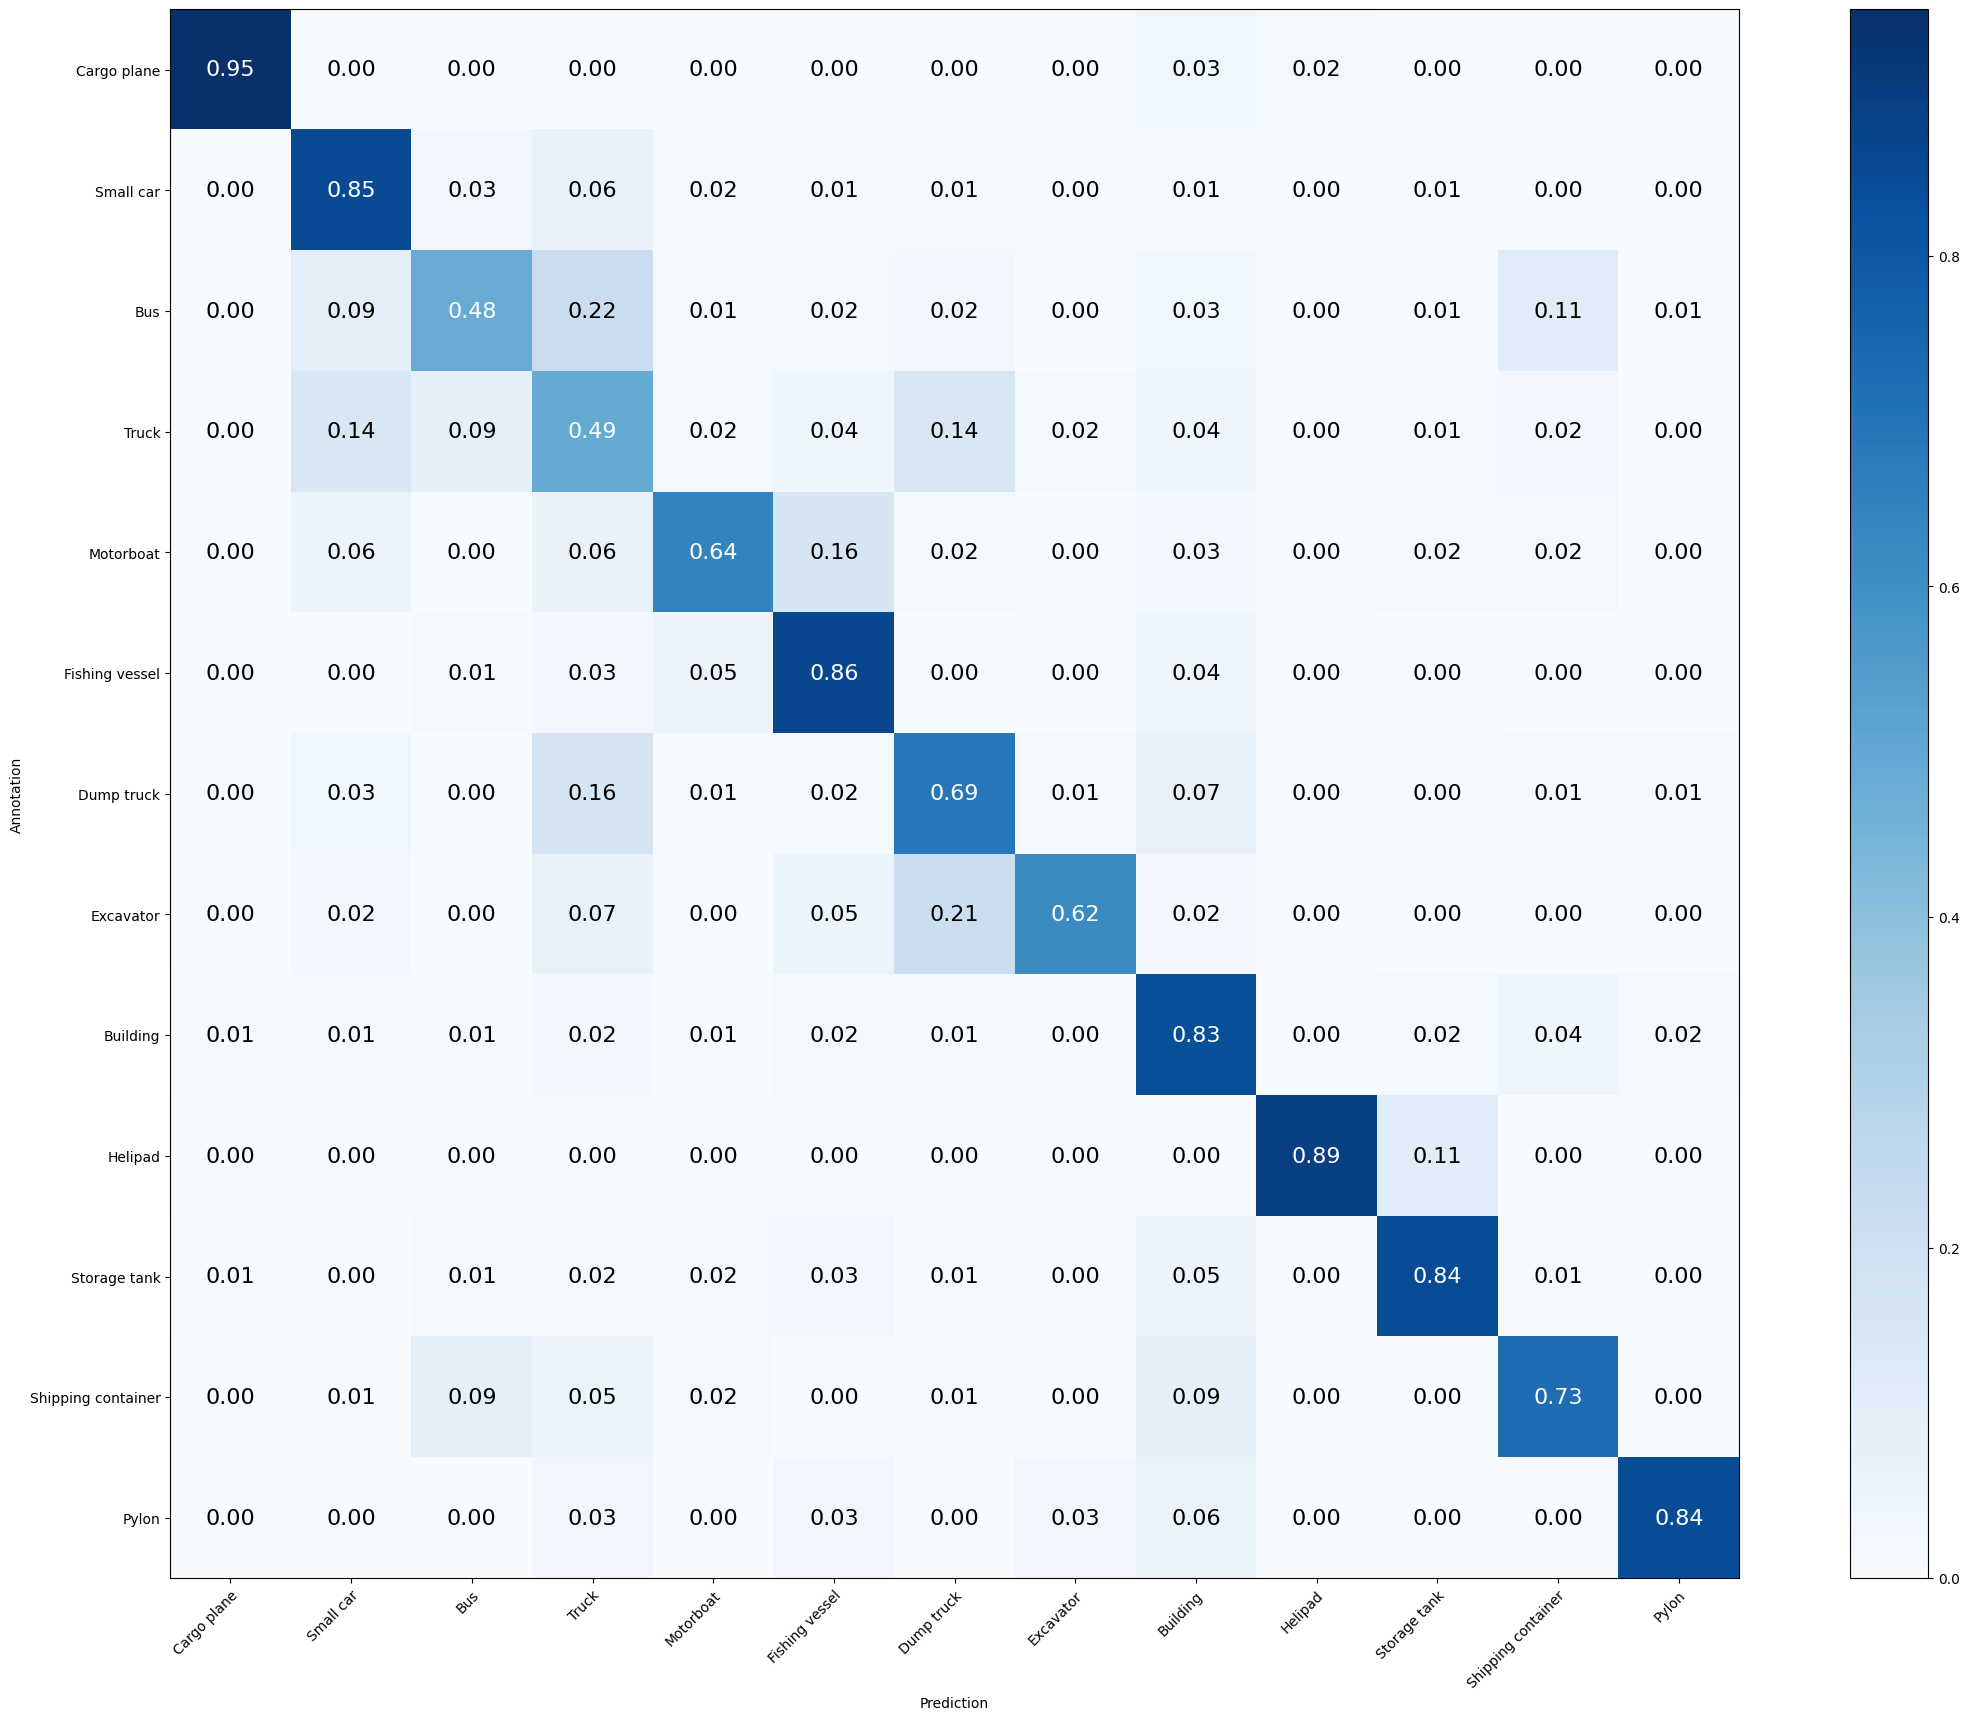

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
%matplotlib inline



def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()


y_true, y_pred = [], []
for ann in anns_valid:
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        y_true.append(obj_pred.category)
        y_pred.append(pred_category)




# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)




In [11]:

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))


Mean Accuracy: 72.800%
Mean Recall: 74.722%
Mean Precision: 74.360%
> Cargo plane: Recall: 94.915% Precision: 93.333% Specificity: 99.780% Dice: 94.118%
> Small car: Recall: 84.802% Precision: 80.870% Specificity: 95.731% Dice: 82.789%
> Bus: Recall: 48.276% Precision: 63.158% Specificity: 97.119% Dice: 54.723%
> Truck: Recall: 48.963% Precision: 51.082% Specificity: 93.084% Dice: 50.000%
> Motorboat: Recall: 64.220% Precision: 73.684% Specificity: 98.584% Dice: 68.627%
> Fishing vessel: Recall: 86.301% Precision: 54.783% Specificity: 97.114% Dice: 67.021%
> Dump truck: Recall: 68.644% Precision: 55.102% Specificity: 96.244% Dice: 61.132%
> Excavator: Recall: 61.728% Precision: 89.286% Specificity: 99.666% Dice: 72.993%
> Building: Recall: 83.471% Precision: 83.934% Specificity: 96.164% Dice: 83.702%
> Helipad: Recall: 88.889% Precision: 88.889% Specificity: 99.946% Dice: 88.889%
> Storage tank: Recall: 84.211% Precision: 89.510% Specificity: 99.129% Dice: 86.780%
> Shipping container:

Testing

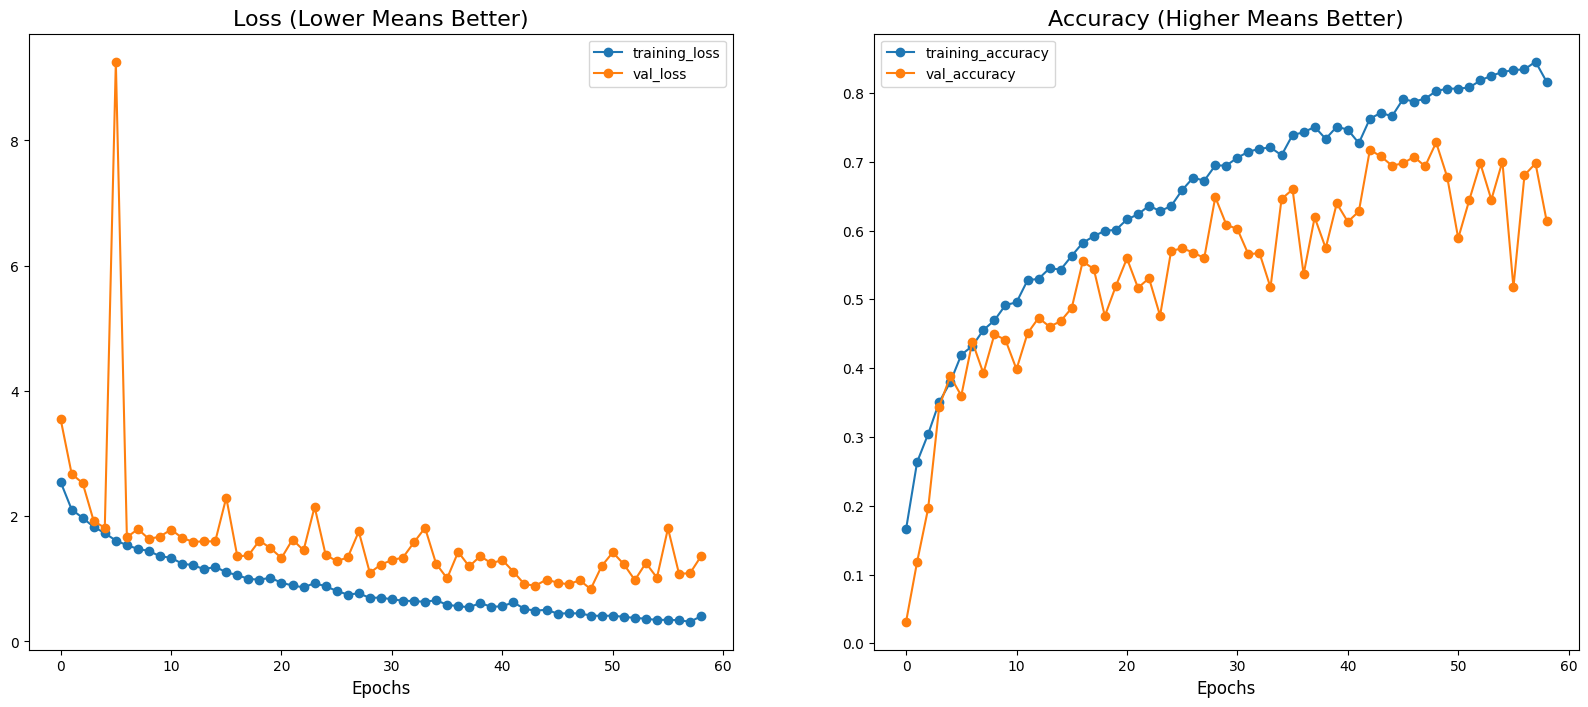

In [12]:

def plot_training_curves(history):
    hist = history.history

    loss = np.array(hist['loss'])
    val_loss = np.array(hist['val_loss'])

    # ---- Find accuracy key automatically ----
    acc_key = None
    for k in hist.keys():
        if 'acc' in k and not k.startswith('val'):
            acc_key = k
            break

    val_acc_key = 'val_' + acc_key if acc_key and ('val_' + acc_key) in hist else None

    if acc_key is None:
        raise KeyError("No accuracy-like entry found in history.history")

    accuracy = np.array(hist[acc_key])
    val_accuracy = np.array(hist[val_acc_key])

    epochs = range(len(loss))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Plot loss
    ax1.plot(epochs, loss, label='training_loss', marker='o')
    ax1.plot(epochs, val_loss, label='val_loss', marker='o')
    ax1.set_title('Loss (Lower Means Better)', fontsize=16)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.legend()

    # Plot accuracy
    ax2.plot(epochs, accuracy, label='training_accuracy', marker='o')
    ax2.plot(epochs, val_accuracy, label='val_accuracy', marker='o')
    ax2.set_title('Accuracy (Higher Means Better)', fontsize=16)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.legend();

    return


#Pongo esto aquí porque si pones dos imágenes en un bloque solo te deja copiar la última
plot_training_curves(history)

In [ ]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('../PROJECT/xview_recognition/xview_test'):
    for filename in filenames:
         # Ruta ABSOLUTA segura
        full_path = os.path.join(dirpath, filename)
        image = GenericImage(full_path)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))


#model.load_weights('model.keras')
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

Number of testing images: 2365


In [ ]:
import os
import numpy as np

predictions_data = {"images": {}, "annotations": {}}
n_classes = 13

# Loss function used during training
loss_fn = tf.keras.losses.CategoricalCrossentropy()

# Counters
total = 0
correct = 0
losses = []


anns = []
for (dirpath, dirnames, filenames) in os.walk('../PROJECT/xview_recognition/xview_test'):
    for filename in filenames:
         # Ruta ABSOLUTA segura
        full_path = os.path.join(dirpath, filename)
        image = GenericImage(full_path)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # Load image
    image = load_geoimage(ann.filename)
    warped_image = np.expand_dims(image, 0)  # (1, H, W, C)

    # ---- PREDICTION ----
    predictions = model.predict(warped_image, verbose=0)  # (1, n_classes)
    pred_probs = predictions[0]                           # (n_classes,)
    pred_idx = np.argmax(pred_probs)

    # ---- TRUE LABEL ----
    # you set obj.category = dir name earlier:
    true_cat = ann.objects[0].category           # e.g. 'vehicle', 'building', ...
    true_idx = cat2idx[true_cat]                 # int in [0..n_classes-1]

    # One-hot for loss (since you used categorical_crossentropy)
    y_true_oh = tf.one_hot(true_idx, depth=n_classes)     # (n_classes,)
    y_true_oh = tf.expand_dims(y_true_oh, axis=0)         # (1, n_classes)
    y_pred = tf.expand_dims(pred_probs, axis=0)           # (1, n_classes)

    # ---- LOSS ----
    loss_value = loss_fn(y_true_oh, y_pred).numpy()
    losses.append(loss_value)

    # ---- ACCURACY ----
    if pred_idx == true_idx:
        correct += 1
    total += 1

# ---- FINAL METRICS ----
test_accuracy = correct / total
test_loss = float(np.mean(losses))

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)


Number of testing images: 2365
Test accuracy: 0.6900634249471459
Test loss: 0.9624281525611877


In [ ]:
with open("prediction_recognition.json", "w") as outfile:
    json.dump(predictions_data, outfile)